## Linear and Non-linear SVM Implementation using Python

**1.** Write a Python program using scikit-learn to: (a) Train a linear SVM classifier (b) Predict output for test data

In [20]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\IIITDMK_SIC44\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [21]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [65]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
print(X.shape, y.shape)

(150, 4) (150,)


In [66]:
# Convert to binary classification
y = np.where(y == 0, -1, 1)

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [68]:
learning_rate = 0.001
lambda_param = 0.01
n_iters = 1000

n_samples, n_features = X_train.shape
print(X_train.shape)
w = np.zeros(n_features)
b = 0

(105, 4)


In [69]:
for _ in range(n_iters):
    for i in range(n_samples):
        condition = y_train[i] * (np.dot(X_train[i], w) - b) >= 1
        
        if condition:
            # Correct classification
            w -= learning_rate * (2 * lambda_param * w)
        else:
            # Misclassification
            w -= learning_rate * (2 * lambda_param * w - y_train[i] * X_train[i])
            b -= learning_rate * y_train[i]

In [70]:
def predict(X):
    linear_output = np.dot(X, w) - b
    return np.sign(linear_output)

In [71]:
y_pred = predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Predictions:", y_pred)
print("Actual:", y_test)
print("Accuracy:", accuracy*100)

Predictions: [ 1. -1.  1.  1.  1. -1.  1.  1.  1.  1.  1. -1. -1. -1. -1.  1.  1.  1.
  1.  1. -1.  1. -1.  1.  1.  1.  1.  1. -1. -1. -1. -1.  1. -1. -1.  1.
  1. -1. -1. -1.  1.  1.  1. -1. -1.]
Actual: [ 1 -1  1  1  1 -1  1  1  1  1  1 -1 -1 -1 -1  1  1  1  1  1 -1  1 -1  1
  1  1  1  1 -1 -1 -1 -1  1 -1 -1  1  1 -1 -1 -1  1  1  1 -1 -1]
Accuracy: 100.0


**2.** Load a dataset (e.g., Iris dataset) and: (a) Train SVM with different kernels (b) Compare accuracy

In [43]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X = iris.data
y = iris.target

y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(X.shape, y.shape)

(150, 4) (150,)


In [46]:
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x1, x2, degree=3):
    return (np.dot(x1, x2) + 1) ** degree

def sigmoid_kernel(x1, x2, alpha=0.01, c=0):
    return np.tanh(alpha * np.dot(x1, x2) + c)

def rbf_kernel(x1, x2, gamma=0.1):    #Gaussian kernel 
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

In [55]:
def train_svm(X, y, kernel, lr=0.001, lambda_param=0.01, n_iters=200):
    n_samples = X.shape[0]
    alpha = np.zeros(n_samples)

    for _ in range(n_iters):
        for i in range(n_samples):
            sum_k = 0
            for j in range(n_samples):
                sum_k += alpha[j] * y[j] * kernel(X[j], X[i])

            condition = y[i] * sum_k

            if condition < 1:
                alpha[i] += lr * (1 - condition - lambda_param * alpha[i])
                
            # CLIP to avoid explosion error
            alpha[i] = np.clip(alpha[i], 0, 1)

    return alpha

In [56]:
def predict(X_train, y_train, alpha, X_test, kernel):
    y_pred = []

    for x in X_test:
        sum_k = 0
        for i in range(len(X_train)):
            sum_k += alpha[i] * y_train[i] * kernel(X_train[i], x)

        y_pred.append(np.sign(sum_k))

    return np.array(y_pred)

In [57]:
kernels = {
    "Linear": linear_kernel,
    "Polynomial": polynomial_kernel,
    "Sigmoid": sigmoid_kernel,
    "RBF (Gaussian)": rbf_kernel
}

In [63]:
for name, kernel in kernels.items():
    alpha = train_svm(X_train, y_train, kernel)
    y_pred = predict(X_train, y_train, alpha, X_test, kernel)
    
    accuracy = np.mean(y_pred == y_test)
    
    print(f"{name} Kernel Accuracy: {accuracy*100:.4f}")

Linear Kernel Accuracy: 100.0000
Polynomial Kernel Accuracy: 100.0000
Sigmoid Kernel Accuracy: 57.7778
RBF (Gaussian) Kernel Accuracy: 100.0000


**3.** Visualize decision boundary for: (a) Linear SVM (b) Non-linear SVM

### Linear SVM

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X = iris.data[:, :2]  # only first 2 features for plotting
y = iris.target
y = np.where(y == 0, -1, 1) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [79]:
learning_rate = 0.001
lambda_param = 0.01
n_iters = 1000

w = np.zeros(X_train.shape[1])
b = 0

for _ in range(n_iters):
    for i, x_i in enumerate(X_train):
        if y_train[i] * (np.dot(x_i, w) - b) >= 1:
            w -= learning_rate * (2 * lambda_param * w)
        else:
            w -= learning_rate * (2 * lambda_param * w - y_train[i] * x_i)
            b -= learning_rate * y_train[i]

In [80]:
def predict(X):
    return np.sign(np.dot(X, w) - b)

### SVM Kernel

In [81]:
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x1, x2, degree=3):
    return (np.dot(x1, x2) + 1) ** degree

def sigmoid_kernel(x1, x2, alpha=0.01, c=0):
    return np.tanh(alpha * np.dot(x1, x2) + c)

def rbf_kernel(x1, x2, gamma=0.5):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

In [82]:
def train_svm(X_train, y_train, kernel, n_iters=500, lr=0.01):
    alpha = np.zeros(len(X_train))
    for _ in range(n_iters):
        for i, x_i in enumerate(X_train):
            s = sum(alpha[j] * y_train[j] * kernel(X_train[j], x_i) for j in range(len(X_train)))
            if y_train[i] * s <= 0:
                alpha[i] += lr
    return alpha

In [83]:
def predict_kernel(X_train, y_train, alpha, X_test, kernel):
    y_pred = []
    for x in X_test:
        s = sum(alpha[i] * y_train[i] * kernel(X_train[i], x) for i in range(len(X_train)))
        y_pred.append(np.sign(s))
    return np.array(y_pred)

In [84]:
def plot_decision_boundary_linear(X, y, predict_func, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_func(grid)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.show()

In [85]:
def plot_decision_boundary_kernel(X_train, y_train, alpha, kernel, title):
    x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
    y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_kernel(X_train, y_train, alpha, grid, kernel)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.show()

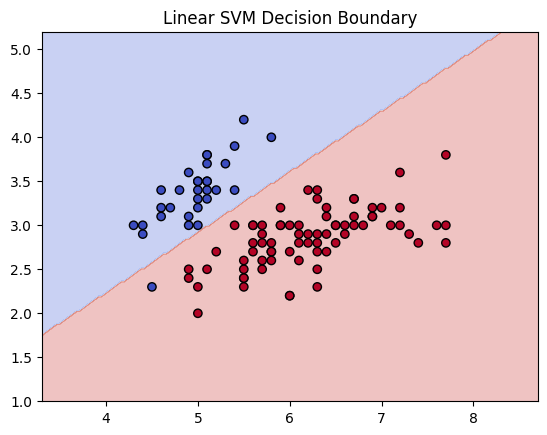

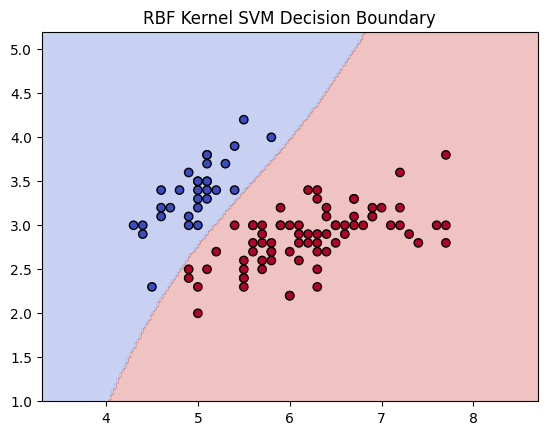

In [87]:
alpha_rbf = train_svm(X_train, y_train, rbf_kernel)
plot_decision_boundary_linear(X_train, y_train, predict, "Linear SVM Decision Boundary")
plot_decision_boundary_kernel(X_train, y_train, alpha_rbf, rbf_kernel, "RBF Kernel SVM Decision Boundary")

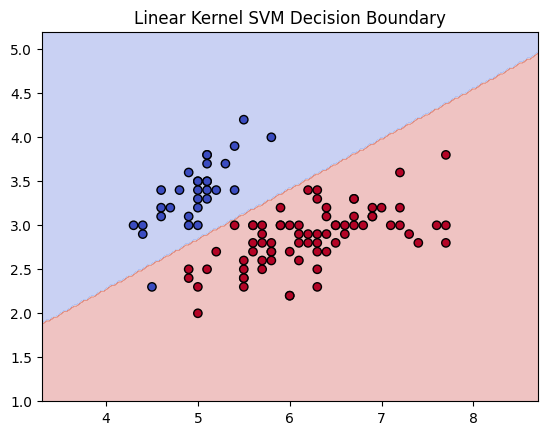

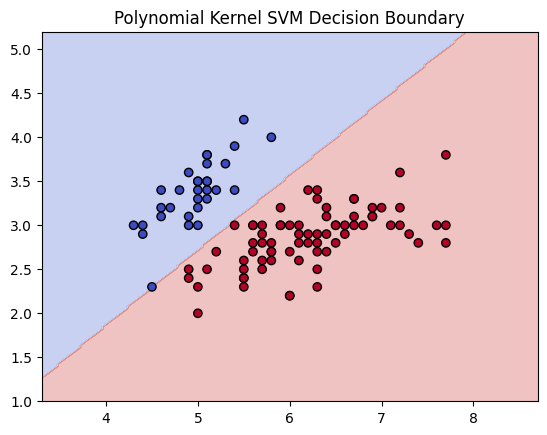

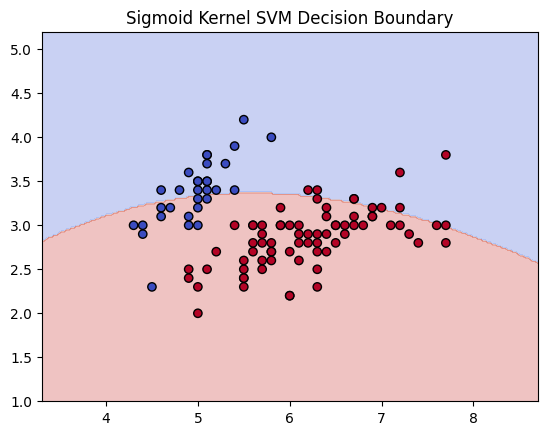

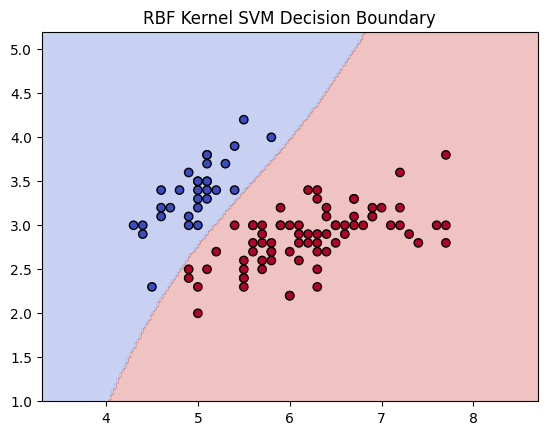

In [88]:
kernels = {
    "Linear": linear_kernel,
    "Polynomial": polynomial_kernel,
    "Sigmoid": sigmoid_kernel,
    "RBF": rbf_kernel
}

for name, kernel_func in kernels.items():
    alpha = train_svm(X_train, y_train, kernel_func)
    plot_decision_boundary_kernel(X_train, y_train, alpha, kernel_func, f"{name} Kernel SVM Decision Boundary")